<a href="https://colab.research.google.com/github/MatiasHerrneder/sistemas-inteligentes-2026/blob/main/mlp-vs-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción

# 2. Carga y Exploración de Datos

### Configuracion inicial

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


VALIDATION_SPLIT = 0.2

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# calcula media y std sobre todo el dataset
raw_dataset = datasets.FashionMNIST(root='./data', train=True, download=True,
                                     transform=transforms.ToTensor())

loader = DataLoader(raw_dataset, batch_size=512, shuffle=False)

mean = 0.0
std  = 0.0
n    = 0

for imgs, _ in loader:
    mean += imgs.mean(dim=[0, 2, 3])
    std  += imgs.std(dim=[0, 2, 3])
    n    += 1

mean /= n
std  /= n

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean.item(),), std=(std.item(),)) #type: ignore
])

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])

train_full = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

val_size   = int(VALIDATION_SPLIT * len(train_full))
train_size = len(train_full) - val_size

# split reproducible
train_set, val_set = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(64))

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

### Forma del tensor

In [2]:
sample_img, sample_label = train_full[0]
shape = tuple(sample_img.shape)
print(f"Channels: {shape[0]}\nHeight: {shape[1]}\nWidth: {shape[2]}")

Channels: 1
Height: 28
Width: 28


### Imagenes de ejemplo

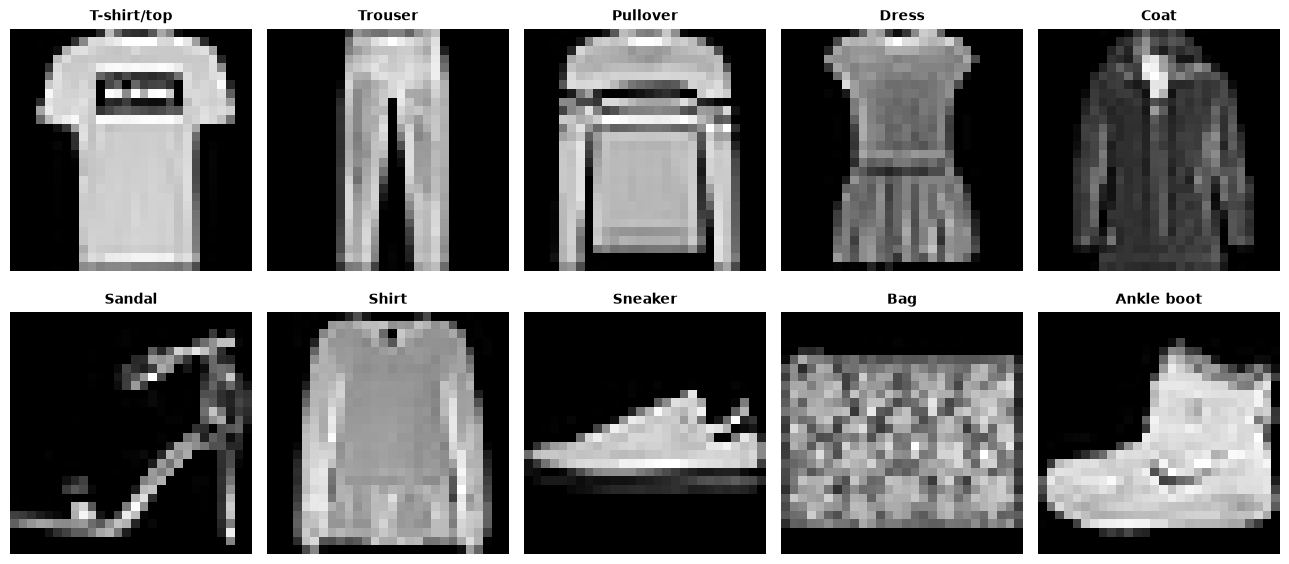

In [3]:
import matplotlib.pyplot as plt

def get_one_per_class(dataset, n_classes=10):
    found = {}
    for img, label in dataset:
        if label not in found:
            found[label] = img
        if len(found) == n_classes:
            break
    return [found[i] for i in range(n_classes)]

samples = get_one_per_class(train_full)

fig1, axes = plt.subplots(2, 5, figsize=(13, 6))

for ax, img, name in zip(axes.flat, samples, CLASS_NAMES):
    # Desnormalizar para mostrar [-1,1] -> [0,1]
    img_np = img.squeeze().numpy()
    img_np = (img_np * 0.5) + 0.5
    ax.imshow(img_np, cmap='gray')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Distribucion de clases

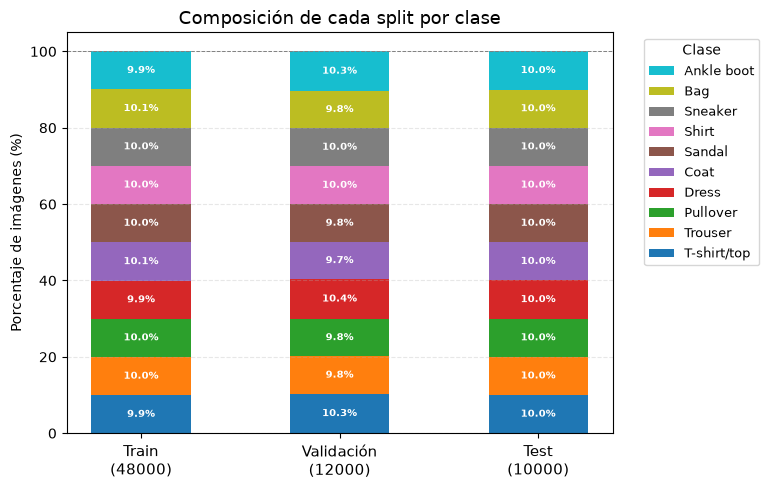

In [4]:
from collections import Counter
import numpy as np

def get_labels(subset):
    if hasattr(subset, 'dataset'):
        return [subset.dataset.targets[i].item() for i in subset.indices]
    else:
        return subset.targets.tolist()

train_labels = get_labels(train_set)
val_labels   = get_labels(val_set)
test_labels  = get_labels(test_set)

def label_counts(labels):
    c = Counter(labels)
    return [c[i] for i in range(10)]

splits = {
    f'Train\n({train_size})': label_counts(train_labels),
    f'Validación\n({val_size})': label_counts(val_labels),
    f'Test\n({len(test_set)})': label_counts(test_labels),
}

splits_pct = {
    name: np.array(counts) / sum(counts) * 100
    for name, counts in splits.items()
}

fig2, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(3)
x = np.arange(3)

for i, class_name in enumerate(CLASS_NAMES):
    values = np.array([splits_pct[split][i] for split in splits_pct])
    bars = ax.bar(x, values, bottom=bottom, label=class_name, width=0.5)

    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 1.5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + val / 2,
                f'{val:.1f}%',
                ha='center', va='center', fontsize=7, color='white', fontweight='bold'
            )
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(list(splits_pct.keys()), fontsize=11)
ax.set_ylabel("Porcentaje de imágenes (%)")
ax.set_title("Composición de cada split por clase", fontsize=13)
ax.set_ylim(0, 105)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.7)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1], labels[::-1],
    loc='upper right', bbox_to_anchor=(1.28, 1), fontsize=9, title="Clase"
)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Rango de valores de los pixeles

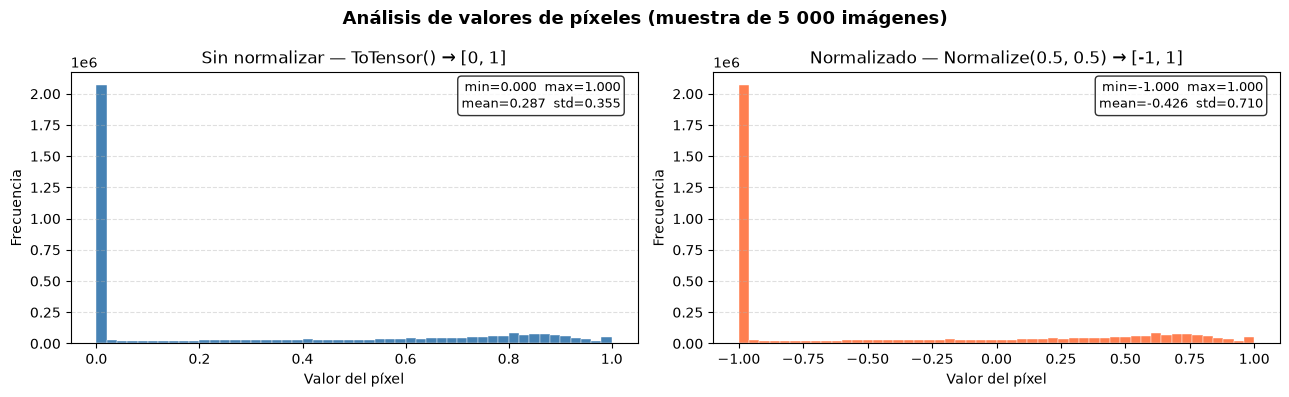

In [5]:
train_counts = label_counts(train_labels)

# calcula stats sobre píxeles RAW (sin normalizar) y normalizados
raw_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=False,
    transform=transforms.ToTensor()
)

# muestra aleatoria de 5000 imagenes
indices = torch.randperm(len(raw_dataset))[:5000]
sample_pixels_raw = torch.stack([raw_dataset[int(i)][0] for i in indices])
sample_pixels_norm = sample_pixels_raw * 2 - 1

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 4))
fig3.suptitle("Análisis de valores de píxeles (muestra de 5 000 imágenes)", fontsize=13, fontweight='bold')

# histograma
ax = axes3[0]
flat_raw = sample_pixels_raw.flatten().numpy()
ax.hist(flat_raw, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title("Sin normalizar — ToTensor() → [0, 1]")
ax.set_xlabel("Valor del píxel")
ax.set_ylabel("Frecuencia")
stats_raw = f"min={flat_raw.min():.3f}  max={flat_raw.max():.3f}\nmean={flat_raw.mean():.3f}  std={flat_raw.std():.3f}"
ax.text(0.97, 0.97, stats_raw, transform=ax.transAxes,
        va='top', ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# histograma normalizado
ax2 = axes3[1]
flat_norm = sample_pixels_norm.flatten().numpy()
ax2.hist(flat_norm, bins=50, color='coral', edgecolor='white', linewidth=0.3)
ax2.set_title("Normalizado — Normalize(0.5, 0.5) → [-1, 1]")
ax2.set_xlabel("Valor del píxel")
ax2.set_ylabel("Frecuencia")
stats_norm = f"min={flat_norm.min():.3f}  max={flat_norm.max():.3f}\nmean={flat_norm.mean():.3f}  std={flat_norm.std():.3f}"
ax2.text(0.97, 0.97, stats_norm, transform=ax2.transAxes,
         va='top', ha='right', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Forma de las imagenes

In [6]:
shapes = set(raw_dataset[int(i)][0].shape for i in indices)
print(f"Formas únicas en el dataset: {shapes}")

Formas únicas en el dataset: {torch.Size([1, 28, 28])}


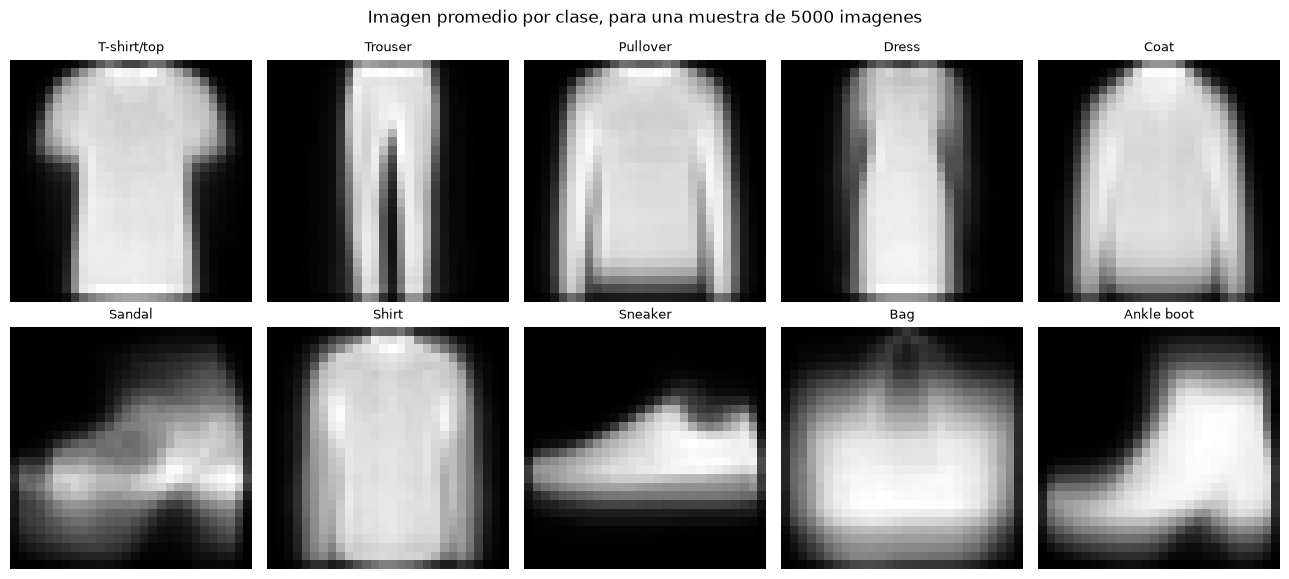

In [7]:
sample_size = min(len(raw_dataset), 5000)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
fig.suptitle(f"Imagen promedio por clase, para una muestra de {sample_size} imagenes")

for class_idx, ax in enumerate(axes.flat):
    imgs = [raw_dataset[int(i)][0] for i in range(sample_size)
            if raw_dataset[int(i)][1] == class_idx]
    mean_img = torch.stack(imgs).mean(dim=0).squeeze()
    ax.imshow(mean_img, cmap='gray')
    ax.set_title(CLASS_NAMES[class_idx], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 3. Preprocesamiento

### Normalizacion de las imagenes
Al inicio de la parte 2, ya se normalizaron las imagenes, para poder hacer correctamente los calculos del analisis, con valores de media y desvio:

In [8]:
print(f"Mean: {mean.item():.4f}") # type: ignore
print(f"Std:  {std.item():.4f}") # type: ignore

Mean: 0.2862
Std:  0.3530


### Aplanado de imagenes

In [9]:
transform_mlp = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean.item(),), std=(std.item(),)),  # type: ignore
    transforms.Lambda(lambda x: x.view(-1))
])

# Cargar datasets
train_full_mlp = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform_mlp
)

test_set_mlp = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform_mlp
)

# Split train/validation
val_size_mlp = int(VALIDATION_SPLIT * len(train_full_mlp))
train_size_mlp = len(train_full_mlp) - val_size_mlp

train_set_mlp, val_set_mlp = random_split(
    train_full_mlp,
    [train_size_mlp, val_size_mlp],
    generator=torch.Generator().manual_seed(64)
)

# DataLoaders
train_loader_mlp = DataLoader(train_set_mlp, batch_size=256, shuffle=True)
val_loader_mlp   = DataLoader(val_set_mlp, batch_size=256, shuffle=False)
test_loader_mlp  = DataLoader(test_set_mlp, batch_size=256, shuffle=False)

print("DataLoaders para MLP creados exitosamente.")
images, labels = next(iter(train_loader_mlp))
print(images.shape)

DataLoaders para MLP creados exitosamente.
torch.Size([256, 784])


# 4. Definición de los Modelos

## Modelo 1: MLP (MultiLayer Feedforward)

### Arquitectura MLP Base

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

### Crear modelo, loss y optimizador

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_mlp = FashionMLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_mlp.parameters(),
    lr=0.001
)

### Función de entrenamiento y evaluación

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

### Entrenamiento del modelo

In [ ]:
num_epochs = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model_mlp,
        train_loader_mlp,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model_mlp,
        val_loader_mlp,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

### Evaluar en test

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

y_true, y_pred = get_predictions(model_mlp, test_loader_mlp, device)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión - MLP")
plt.show()

test_loss, test_acc = evaluate(
    model_mlp,
    test_loader_mlp,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

In [ ]:
class FlexibleMLP(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size, activation, dropout):
        super().__init__()

        layers = []
        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(activation())
            layers.append(nn.Dropout(dropout))
            previous_size = hidden_size

        layers.append(nn.Linear(previous_size, output_size))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [ ]:
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [ ]:
def get_optimizer(name, model, lr):
    if name == "Adam":
        return optim.Adam(model.parameters(), lr=lr)

    elif name == "SGD":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    elif name == "RMSprop":
        return optim.RMSprop(model.parameters(), lr=lr)

    else:
        raise ValueError(f"Optimizador no soportado: {name}")

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

    return history

In [ ]:
experiments = [
    {
        "name": "MLP_256_128_ReLU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.ReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_512_256_128_ReLU_Adam",
        "hidden_layers": [512, 256, 128],
        "activation": nn.ReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_256_128_LeakyReLU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.LeakyReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_256_128_GELU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.GELU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_512_256_ReLU_RMSprop",
        "hidden_layers": [512, 256],
        "activation": nn.ReLU,
        "dropout": 0.2,
        "optimizer": "RMSprop",
        "lr": 0.0005,
        "epochs": 15
    }
]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = []

criterion = nn.CrossEntropyLoss()

for exp in experiments:
    print(f"Entrenando experimento: {exp['name']}")

    model = FlexibleMLP(
        input_size=784,
        hidden_layers=exp["hidden_layers"],
        output_size=10,
        activation=exp["activation"],
        dropout=exp["dropout"]
    ).to(device)

    optimizer = get_optimizer(
        name=exp["optimizer"],
        model=model,
        lr=exp["lr"]
    )

    history = train_model(
        model=model,
        train_loader=train_loader_mlp,
        val_loader=val_loader_mlp,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=exp["epochs"]
    )

    y_true, y_pred = get_predictions(
        model,
        test_loader_mlp,
        device
    )

    test_acc = accuracy_score(y_true, y_pred)
    test_precision = precision_score(y_true, y_pred, average="macro")
    test_recall = recall_score(y_true, y_pred, average="macro")
    test_f1 = f1_score(y_true, y_pred, average="macro")

    results.append({
        "model": exp["name"],
        "hidden_layers": exp["hidden_layers"],
        "activation": exp["activation"].__name__,
        "dropout": exp["dropout"],
        "optimizer": exp["optimizer"],
        "lr": exp["lr"],
        "epochs": exp["epochs"],
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "test_acc": test_acc,
        "test_precision_macro": test_precision,
        "test_recall_macro": test_recall,
        "test_f1_macro": test_f1
    })

    print(f"Finalizado: {exp['name']}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test F1 Macro: {test_f1:.4f}")
    print("-" * 50)

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["test_acc", "test_f1_macro"],
    ascending=False
)

results_df

## Modelo 2: CNN (Convolucional)

### Arquitectura CNN Base

In [20]:
import torch
from torch import optim
from torch import nn
from tqdm import tqdm
from dataclasses import dataclass, field
from typing import Literal

# import torchvision

import torch.nn.functional as F
# import torchvision.datasets as datasets
# import torchvision.transforms as transforms

############################
# configuracion de la cnn
############################
@dataclass
class ConvLayerConfig:
    out_channels: int
    kernel_size: int = 3
    padding: int = 1
    activation: Literal["relu", "tanh", "leaky_relu", "elu", "none"] = "relu"
    pooling: Literal["max", "avg", "none"] = "max"
    use_batchnorm: bool = False
    dropout_p: float = 0.0

@dataclass
class LinearLayerConfig:
    out_features: int
    activation: Literal["relu", "tanh", "leaky_relu", "elu", "none"] = "relu"
    dropout_p: float = 0.0

@dataclass
class TrainConfig:
    num_epochs:   int   = 10
    lr:           float = 0.001
    weight_decay: float = 0.0      # L2 — 0.0 = desactivado
    l1_lambda:    float = 0.0      # L1 — 0.0 = desactivado
    patience:     int   = 0        # early stopping — 0 = desactivado


##################
# helpers
##################
ACTIVATIONS = {
    "relu":       nn.ReLU(),
    "tanh":       nn.Tanh(),
    "leaky_relu": nn.LeakyReLU(),
    "elu":        nn.ELU(),
    "none":       nn.Identity(),
}

POOLING = {
    "max": nn.MaxPool2d(kernel_size=2, stride=2),
    "avg": nn.AvgPool2d(kernel_size=2, stride=2),
    "none": nn.Identity(),
}


######################
# modelo
######################
class CNN(nn.Module):
    def __init__(
        self, 
        in_channels: int, 
        input_size: int, # ancho, alto de la img
        num_classes: int,
        conv_layers: list[ConvLayerConfig],
        linear_layers: list[LinearLayerConfig],
        ):
       
        super().__init__()

        conv_blocks = []
        current_channels = in_channels

        for cfg in conv_layers:
            conv_blocks += [
                nn.Conv2d(current_channels, cfg.out_channels,
                          kernel_size=cfg.kernel_size, padding=cfg.padding),
                nn.BatchNorm2d(cfg.out_channels) if cfg.use_batchnorm else nn.Identity(),
                ACTIVATIONS[cfg.activation],
                POOLING[cfg.pooling],
                nn.Dropout2d(cfg.dropout_p) if cfg.dropout_p > 0 else nn.Identity(),
            ]
            current_channels = cfg.out_channels
            if cfg.pooling != "none":
                input_size //= 2

        self.conv_net = nn.Sequential(*conv_blocks)

        flatten_size = current_channels * input_size * input_size
        linear_blocks = []
        current_features = flatten_size

        for cfg in linear_layers:
            linear_blocks += [
                nn.Linear(current_features, cfg.out_features),
                ACTIVATIONS[cfg.activation],
                nn.Dropout(cfg.dropout_p) if cfg.dropout_p > 0 else nn.Identity(),
            ]
            current_features = cfg.out_features

        linear_blocks.append(nn.Linear(current_features, num_classes))
        self.linear_net = nn.Sequential(*linear_blocks)


    def forward(self, x):
        x = self.conv_net(x)
        x = x.reshape(x.shape[0], -1)
        x = self.linear_net(x)
        return x


### Función de entrenamiento y evaluación

In [21]:
def train(
    model:        CNN,
    train_loader,
    val_loader,
    cfg:          TrainConfig,
    device:       str = "cuda" if torch.cuda.is_available() else "cpu",
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_val_loss     = float('inf')
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(cfg.num_epochs):

        # ── Training ───────────────────────────────────────────
        model.train()
        train_loss = 0.0

        for data, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.num_epochs}"):
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()
            scores = model(data)
            loss   = criterion(scores, targets)

            if cfg.l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss    = loss + cfg.l1_lambda * l1_norm

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ── Validation ─────────────────────────────────────────
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for data, targets in val_loader:
                data, targets = data.to(device), targets.to(device)
                val_loss += criterion(model(data), targets).item()

        val_loss /= len(val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"  train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

        # ── Early stopping ─────────────────────────────────────
        if cfg.patience > 0:
            if val_loss < best_val_loss:
                best_val_loss     = val_loss
                epochs_no_improve = 0
                torch.save(model.state_dict(), "best_model.pth")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= cfg.patience:
                    print(f"  Early stopping en época {epoch+1}")
                    model.load_state_dict(torch.load("best_model.pth"))
                    break

    return model, history

### Entrenamiento del modelo

In [ ]:
# device = "cuda" if torch.cuda.is_available() else "cpu"

# model = CNN(in_channels=1, num_classes=10).to(device) # 1 channel: grayscale, 10 clases: 10 tipos de ropa
# print(model)

# # Define the loss function
# criterion = nn.CrossEntropyLoss()

# # Define the optimizer
# optimizer = optim.Adam(model.parameters(), lr=0.001)


# num_epochs=10
# for epoch in range(num_epochs):
#     # Iterate over training batches
#     print(f"Epoch [{epoch + 1}/{num_epochs}]")

#     for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
#         data = data.to(device)
#         targets = targets.to(device)
#         scores = model(data)
#         loss = criterion(scores, targets)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

CNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)
Epoch [1/10]


100%|██████████| 188/188 [00:09<00:00, 18.81it/s]


Epoch [2/10]


100%|██████████| 188/188 [00:07<00:00, 24.40it/s]


Epoch [3/10]


...

100%|██████████| 188/188 [00:07<00:00, 25.45it/s]


Epoch [9/10]


100%|██████████| 188/188 [00:07<00:00, 24.51it/s]


Epoch [10/10]


100%|██████████| 188/188 [00:07<00:00, 24.94it/s]


### Evaluar en test

In [22]:
experiments = [
    {
        "name": "baseline",
        "conv_layers": [
            ConvLayerConfig(out_channels=8),
            ConvLayerConfig(out_channels=16),
        ],
        "linear_layers": [
            LinearLayerConfig(out_features=128),
        ],
        "train_cfg": TrainConfig(),
    },
    {
        "name": "l2 + dropout",
        "conv_layers": [
            ConvLayerConfig(out_channels=32, use_batchnorm=True),
            ConvLayerConfig(out_channels=64, use_batchnorm=True, dropout_p=0.25),
        ],
        "linear_layers": [
            LinearLayerConfig(out_features=256, dropout_p=0.5),
            LinearLayerConfig(out_features=128, dropout_p=0.25),
        ],
        "train_cfg": TrainConfig(weight_decay=1e-4, patience=3),
    },
    {
        "name": "l1 + early stopping",
        "conv_layers": [
            ConvLayerConfig(out_channels=32, use_batchnorm=True),
            ConvLayerConfig(out_channels=64, use_batchnorm=True),
        ],
        "linear_layers": [
            LinearLayerConfig(out_features=128),
        ],
        "train_cfg": TrainConfig(l1_lambda=1e-5, patience=3),
    },
    {
        "name": "todo",
        "conv_layers": [
            ConvLayerConfig(out_channels=32, use_batchnorm=True, activation="leaky_relu"),
            ConvLayerConfig(out_channels=64, use_batchnorm=True, dropout_p=0.25),
        ],
        "linear_layers": [
            LinearLayerConfig(out_features=256, dropout_p=0.5),
            LinearLayerConfig(out_features=128, dropout_p=0.25),
        ],
        "train_cfg": TrainConfig(l1_lambda=1e-5, weight_decay=1e-4, patience=3),
    },
]

results = {}

for exp in experiments:
    print(f"\n{'='*40}\nExperimento: {exp['name']}\n{'='*40}")

    model = CNN(
        in_channels=1,
        input_size=28,
        num_classes=10,
        conv_layers=exp["conv_layers"],
        linear_layers=exp["linear_layers"],
    )

    trained_model, history = train(
        model, train_loader, val_loader, cfg=exp["train_cfg"]
    )

    results[exp["name"]] = history


Experimento: baseline


Epoch 1/10: 100%|██████████| 188/188 [00:07<00:00, 25.66it/s]


  train_loss: 0.6939 | val_loss: 0.4903


Epoch 2/10: 100%|██████████| 188/188 [00:07<00:00, 25.55it/s]


  train_loss: 0.4253 | val_loss: 0.3750


...

  train_loss: 0.3590 | val_loss: 0.2410


Epoch 9/10: 100%|██████████| 188/188 [00:08<00:00, 23.19it/s]


  train_loss: 0.3564 | val_loss: 0.2185


Epoch 10/10: 100%|██████████| 188/188 [00:08<00:00, 23.20it/s]


  train_loss: 0.3449 | val_loss: 0.2193


### Load and save models

In [ ]:
# Save the model
torch.save(model.state_dict(), 'MulticlassCNN.pth')

# Create a new model
loaded_model = CNN(in_channels=1, num_classes=10)

# Load the saved model
loaded_model.load_state_dict(torch.load('MulticlassCNN.pth'))
print(loaded_model)

# 5. Experimentación

# 6. Discusión

# 7. Conclusiones y Trabajo Futuro